In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# df = pd.read_csv("APPLE_PRODUCT_ANALYSIS\apple_products_pricing_2020_2026.csv")
df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\power bi\\APPLE_PRODUCT_ANALYSIS\\apple_products_pricing_2020_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
print(df.dtypes)
print(df.describe())

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
Sale_Event                      str
Stock_Status                    str
Rating                      float64
Reviews_Count                 int64
dtype: object
                             Date  Launch_Price_USD  Launch_Price_INR  \
count                       80000      80000.000000      80000.000000   
mean   2024-09-14 22:14:06.360000        963.959125      94467.994250   
min           2020-09-19 00:00:00        329.000000      32242.000000   
25%           2023-11-03 00:00:00        599.000000      58702.000000   
50%           2024-12-22 00:00:00        799.000000      78302.000000   
75%           2025-10-27 00:00:00       1199

In [4]:

print(df.isnull().sum())
df["Sale_Event"] = df["Sale_Event"].fillna("NORMAL DAYS")
print(df["Sale_Event"].value_counts())



Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64
Sale_Event
NORMAL DAYS              73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64


In [5]:
print(df.dtypes)

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
Sale_Event                      str
Stock_Status                    str
Rating                      float64
Reviews_Count                 int64
dtype: object


In [6]:
platform_wise_pricing_with_product = df.groupby(["Platform","Product_Category","Model_Name"])[["Launch_Price_INR"]].mean()
print(platform_wise_pricing_with_product)

# df_flip_iphone_15 = df[(df["Platform"] == "Flipkart") & (df["Product_Category"] == "iPhone")  ][["Launch_Price_INR","Model_Name"]]
# print(df_flip_iphone_15)

                                                            Launch_Price_INR
Platform Product_Category Model_Name                                        
Amazon   Mac              MacBook Air M1 256GB                       97902.0
                          MacBook Air M2 256GB                      117502.0
                          MacBook Air M3 256GB                      107702.0
                          MacBook Pro 14-inch M1 Pro 512GB          195902.0
                          MacBook Pro 14-inch M2 Pro 512GB          195902.0
...                                                                      ...
Flipkart iPhone           iPhone 15 128GB                            78302.0
                          iPhone 15 Pro Max 256GB                   117502.0
                          iPhone 16 128GB                            78302.0
                          iPhone 16 Pro 256GB                       107702.0
                          iPhone 17 128GB                            83202.0

In [7]:
platform_wise_sales_count = df["Platform"].value_counts()
print("SALES OF EACH FLATFORM: ",platform_wise_sales_count)
platform_wise_pricing_ = df.groupby(["Platform","Product_Category"])[["Launch_Price_INR"]].count()
print(platform_wise_pricing_)
platform_wise_pricing_.to_csv("platform_wise_pricing_.csv")


SALES OF EACH FLATFORM:  Platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64
                           Launch_Price_INR
Platform Product_Category                  
Amazon   Mac                           9083
         Watch                         8842
         iPad                          7788
         iPhone                       14244
Flipkart Mac                           8937
         Watch                         9023
         iPad                          7738
         iPhone                       14345


In [47]:
total_product = df["Product_Category"].value_counts()
print(df["Product_Category"].value_counts())
total_product.to_csv("total.csv")


Product_Category
iPhone    28589
Mac       18020
Watch     17865
iPad      15526
Name: count, dtype: int64


In [43]:
total_product = df["Model_Name"].drop_duplicates()
print(total_product)

0             Apple Watch Series 6 (44mm)
34                iPad Air (4th Gen) 64GB
35                         iPhone 12 64GB
36                    iPhone 12 Pro 128GB
163                  MacBook Air M1 256GB
1411          iPad Pro 11-inch (M1) 128GB
2357                      iPhone 13 128GB
2361              iPhone 13 Pro Max 256GB
2368                  iPad (9th Gen) 64GB
2597          Apple Watch Series 7 (45mm)
2751     MacBook Pro 14-inch M1 Pro 512GB
4876              iPad Air (5th Gen) 64GB
6821                 MacBook Air M2 256GB
7923          Apple Watch Series 8 (45mm)
7937                      iPhone 14 128GB
7939                  iPhone 14 Pro 128GB
8095                    Apple Watch Ultra
8926        iPad Pro 12.9-inch (M2) 256GB
11382    MacBook Pro 14-inch M2 Pro 512GB
18394         Apple Watch Series 9 (45mm)
18397                 Apple Watch Ultra 2
18422                     iPhone 15 128GB
18423             iPhone 15 Pro Max 256GB
20138    MacBook Pro 14-inch M3 Pr

In [40]:
# result = df[df["Product_Category"] == "iPhone"]["Model_Name","Launch_Price_INR"].drop_duplicates()
result_iphone = df[df["Product_Category"] == "iPhone"][
    ["Model_Name", "Launch_Price_INR"]
].drop_duplicates()

print(result_iphone)

result_iphone.to_csv("iphone_20-26.csv")

                    Model_Name  Launch_Price_INR
35              iPhone 12 64GB             78302
36         iPhone 12 Pro 128GB             97902
2357           iPhone 13 128GB             78302
2361   iPhone 13 Pro Max 256GB            117502
7937           iPhone 14 128GB             78302
7939       iPhone 14 Pro 128GB             97902
18422          iPhone 15 128GB             78302
18423  iPhone 15 Pro Max 256GB            117502
34382          iPhone 16 128GB             78302
34383      iPhone 16 Pro 256GB            107702
57312          iPhone 17 128GB             83202


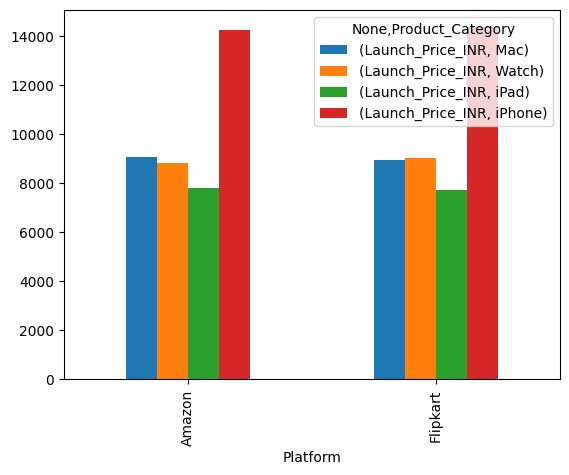

In [ ]:
platform_wise_pricing_gra = df.groupby(["Platform","Product_Category"])[["Launch_Price_INR"]].count()

platform_wise_pricing_graph = df.groupby(["Platform","Product_Category"])[["Launch_Price_INR"]].count().unstack().plot(kind="bar")
plt.show()


In [9]:
# ,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR..

item_condition_wise_price = df.groupby(["Model_Name","Condition"])[["Launch_Price_INR"]].mean()
print(item_condition_wise_price)

# item_condition_wise_price.to_excel("MODEL_CONDITION_WISE_PRICE.xlsx") ##

                                                 Launch_Price_INR
Model_Name                  Condition                            
Apple Watch Series 6 (44mm) New                           42042.0
                            Renewed/Refurbished           42042.0
Apple Watch Series 7 (45mm) New                           42042.0
                            Renewed/Refurbished           42042.0
Apple Watch Series 8 (45mm) New                           42042.0
...                                                           ...
iPhone 16 128GB             Renewed/Refurbished           78302.0
iPhone 16 Pro 256GB         New                          107702.0
                            Renewed/Refurbished          107702.0
iPhone 17 128GB             New                           83202.0
                            Renewed/Refurbished           83202.0

[62 rows x 1 columns]


Sale_Event
NORMAL DAYS              73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64
Platform  Sale_Event           
Amazon    Black Friday              1219
          Great Indian Festival     1504
          NORMAL DAYS              36165
          Prime Day                 1069
Flipkart  Big Billion Days          1579
          Black Friday              1278
          NORMAL DAYS              37186
Name: Sale_Event, dtype: int64
Platform  Model_Name                   Sale_Event           
Amazon    Apple Watch Series 6 (44mm)  Black Friday             23947.905143
                                       Great Indian Festival    22544.999038
                                       NORMAL DAYS              27280.415237
                                       Prime Day                22514.873529
          Apple Watch Series 7 (45mm)  Black Friday             24687.309130
            

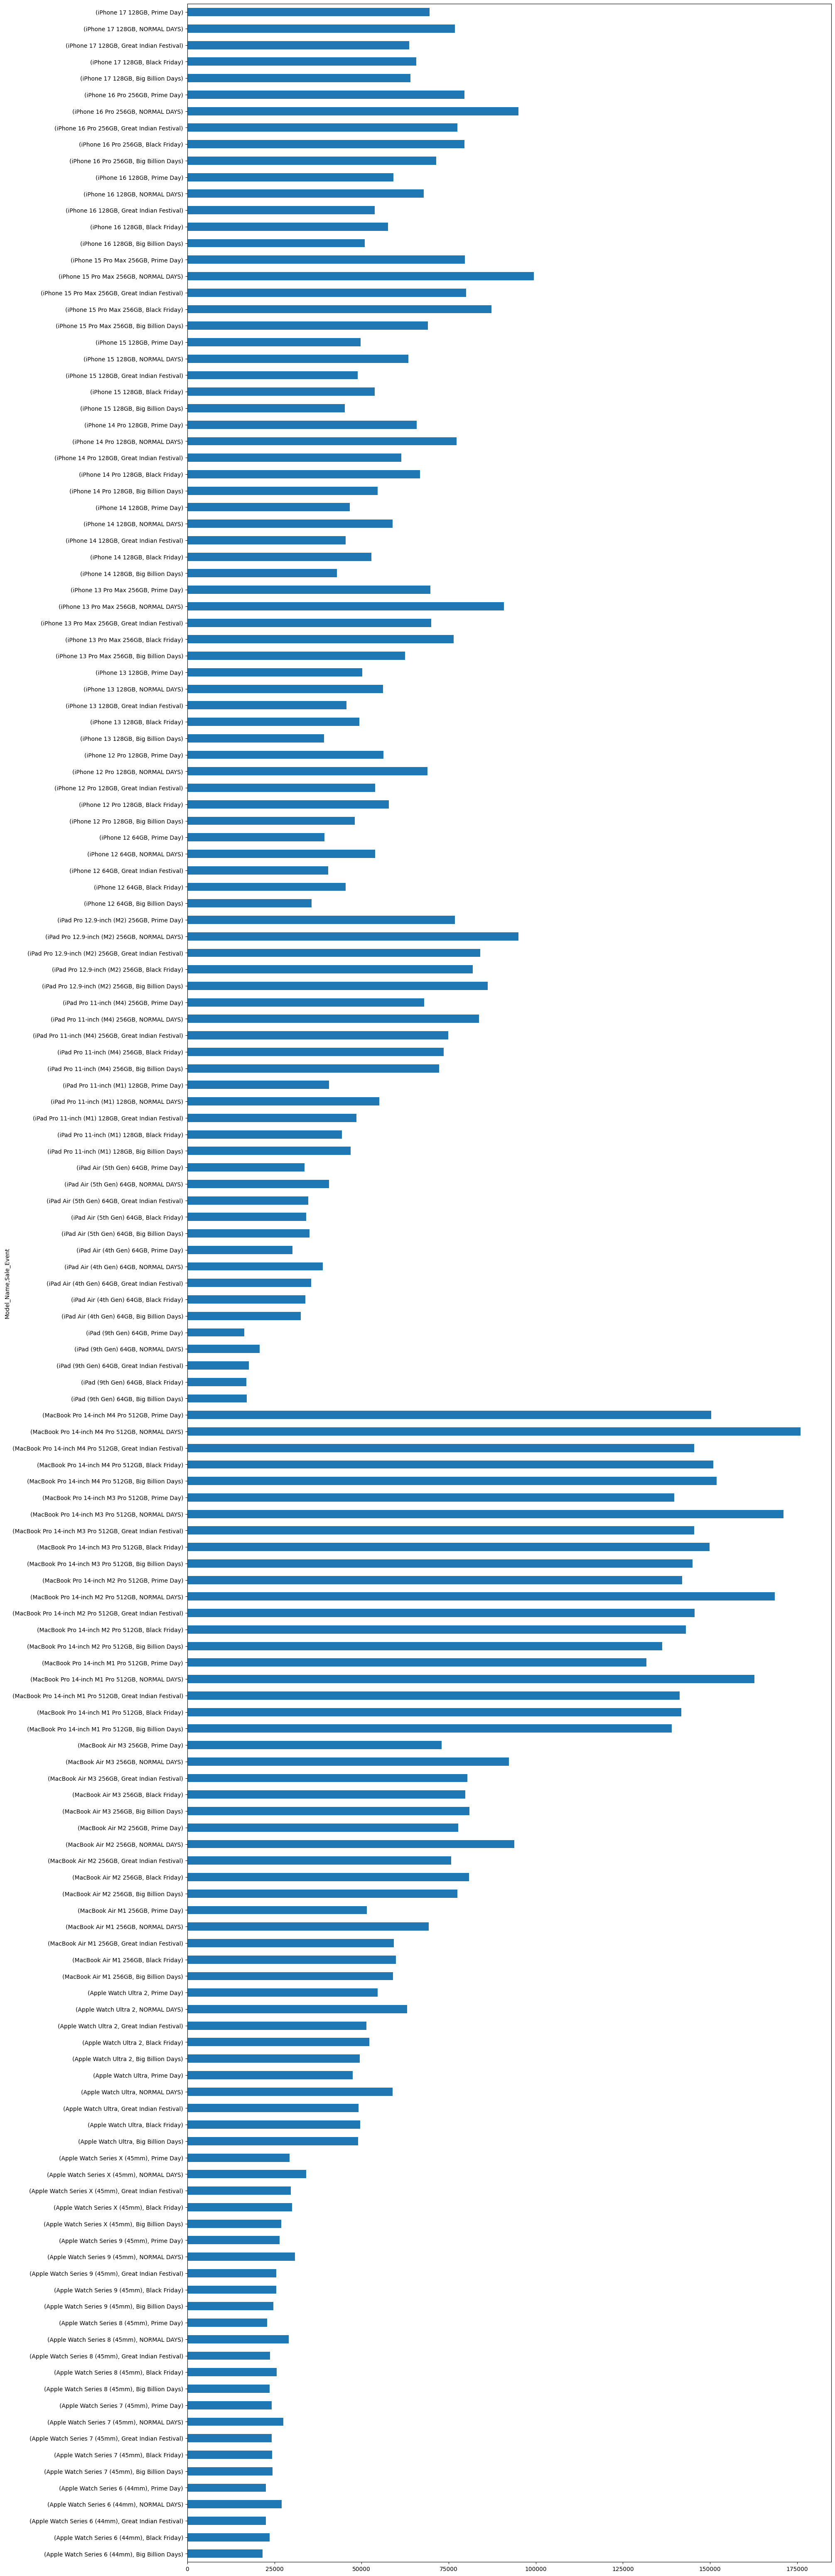

In [10]:
# SALE EVENT BY PRICE

print(df["Sale_Event"].value_counts())
which_sale_for_which_platform = df.groupby(["Platform","Sale_Event"])["Sale_Event"].count()
print(which_sale_for_which_platform)
sale_by_event_with_which_platform_revenue = df.groupby(["Platform","Model_Name","Sale_Event"])["Current_Price_INR"].mean()
print(sale_by_event_with_which_platform_revenue)

sale_by_event_with_which_platform_revenue = df.groupby(["Model_Name","Sale_Event"])["Current_Price_INR"].mean().plot(kind="barh",figsize=(20,80))
plt.show()


In [11]:
print(df["Launch_Price_INR"].value_counts())

Launch_Price_INR
78302     20512
42042     12828
97902     10463
195902    10271
117502    10217
58702      5260
107702     5224
83202      2652
32242      2573
Name: count, dtype: int64


In [12]:
# how much model is come from 2020-26 to all ios gadget

cat_model_type_count = df.groupby(["Product_Category","Model_Name"])["Launch_Price_INR"].mean()
print(cat_model_type_count)

Product_Category  Model_Name                      
Mac               MacBook Air M1 256GB                 97902.0
                  MacBook Air M2 256GB                117502.0
                  MacBook Air M3 256GB                107702.0
                  MacBook Pro 14-inch M1 Pro 512GB    195902.0
                  MacBook Pro 14-inch M2 Pro 512GB    195902.0
                  MacBook Pro 14-inch M3 Pro 512GB    195902.0
                  MacBook Pro 14-inch M4 Pro 512GB    195902.0
Watch             Apple Watch Series 6 (44mm)          42042.0
                  Apple Watch Series 7 (45mm)          42042.0
                  Apple Watch Series 8 (45mm)          42042.0
                  Apple Watch Series 9 (45mm)          42042.0
                  Apple Watch Series X (45mm)          42042.0
                  Apple Watch Ultra                    78302.0
                  Apple Watch Ultra 2                  78302.0
iPad              iPad (9th Gen) 64GB                  32242.0
    

In [13]:
cat_wise_pivot = df.pivot_table(
    index=["Product_Category"],
    columns="Platform",
    values="Current_Price_INR",
    aggfunc="mean"
).round(3)
print(cat_wise_pivot)

cat_wise_pivot.to_csv("cat_wise_pivot.csv")

Platform              Amazon    Flipkart
Product_Category                        
Mac               132170.471  131356.807
Watch              37878.068   38086.391
iPad               54239.203   55031.063
iPhone             72215.248   72525.379


In [14]:
platform_pivot = df.pivot_table(
    index=['Model_Name'],
    columns='Platform',
    values='Current_Price_INR',
    aggfunc='mean'
).round(2)
print(platform_pivot)

Platform                             Amazon   Flipkart
Model_Name                                            
Apple Watch Series 6 (44mm)        26864.15   26569.91
Apple Watch Series 7 (45mm)        27708.04   26883.92
Apple Watch Series 8 (45mm)        28792.55   28537.99
Apple Watch Series 9 (45mm)        30590.18   30172.21
Apple Watch Series X (45mm)        33733.02   33611.87
Apple Watch Ultra                  57668.30   58403.44
Apple Watch Ultra 2                61420.06   62754.67
MacBook Air M1 256GB               67855.27   68961.47
MacBook Air M2 256GB               92525.42   92450.19
MacBook Air M3 256GB               90806.53   91429.32
MacBook Pro 14-inch M1 Pro 512GB  160878.97  160558.38
MacBook Pro 14-inch M2 Pro 512GB  167110.54  166155.09
MacBook Pro 14-inch M3 Pro 512GB  168553.58  169945.49
MacBook Pro 14-inch M4 Pro 512GB  173776.08  174460.10
iPad (9th Gen) 64GB                20534.83   20394.25
iPad Air (4th Gen) 64GB            38730.20   38188.42
iPad Air (

In [15]:
product_wise_discount_by_platforms = df.pivot_table(
    index="Product_Category",
    columns="Platform",
    values="Discount_Pct",
    aggfunc="mean"
).round(3)
print(product_wise_discount_by_platforms)

product_wise_discount_by_platforms.to_csv("product_wise_discount_by_platforms.csv")


Platform          Amazon  Flipkart
Product_Category                  
Mac               15.523    15.337
Watch             26.192    26.340
iPad              26.337    26.042
iPhone            19.797    19.350


In [ ]:
model_wise_discount_by_platforms = df.pivot_table(
    index="Model_Name",
    columns="Platform",
    values="Discount_Pct",
    aggfunc="mean"
).round(3)
print(model_wise_discount_by_platforms)

Platform                          Amazon  Flipkart
Model_Name                                        
Apple Watch Series 6 (44mm)       34.466    34.917
Apple Watch Series 7 (45mm)       32.317    34.112
Apple Watch Series 8 (45mm)       29.824    30.284
Apple Watch Series 9 (45mm)       25.229    26.164
Apple Watch Series X (45mm)       17.459    17.548
Apple Watch Ultra                 24.181    23.350
Apple Watch Ultra 2               19.095    17.655
MacBook Air M1 256GB              28.592    27.533
MacBook Air M2 256GB              18.878    19.046
MacBook Air M3 256GB              13.428    12.796
MacBook Pro 14-inch M1 Pro 512GB  15.591    15.680
MacBook Pro 14-inch M2 Pro 512GB  12.561    12.703
MacBook Pro 14-inch M3 Pro 512GB  11.428    10.876
MacBook Pro 14-inch M4 Pro 512GB   8.804     8.396
iPad (9th Gen) 64GB               34.425    34.908
iPad Air (4th Gen) 64GB           32.240    32.847
iPad Air (5th Gen) 64GB           30.007    29.301
iPad Pro 11-inch (M1) 128GB    

In [23]:
# rating
avg_rating_of_product_head = df.groupby("Model_Name").agg(
    rating_avg=("Rating", "mean"),
    # review_count=("Reviews_Count", "count")
).sort_values(by="rating_avg",ascending=False).head(10)

print(avg_rating_of_product_head)

avg_rating_of_product_head.to_csv("top_10_rating_product.csv")


                                  rating_avg
Model_Name                                  
Apple Watch Series 8 (45mm)         4.462663
MacBook Air M3 256GB                4.461452
iPhone 14 Pro 128GB                 4.459766
iPhone 17 128GB                     4.458296
iPhone 14 128GB                     4.457114
MacBook Pro 14-inch M3 Pro 512GB    4.454927
iPad Air (5th Gen) 64GB             4.454859
iPhone 13 128GB                     4.454280
iPhone 12 64GB                      4.453220
iPhone 16 128GB                     4.452162


In [18]:



# rating
avg_rating_of_product_tail = df.groupby("Model_Name").agg(
    rating_avg=("Rating", "mean"),
    review_count=("Reviews_Count", "count")
).sort_values(by="rating_avg",ascending=True).head(20)

print(avg_rating_of_product_tail)

                                  rating_avg  review_count
Model_Name                                                
Apple Watch Ultra 2                 4.439029          2493
Apple Watch Series X (45mm)         4.440992          2520
iPhone 13 Pro Max 256GB             4.442992          2547
iPhone 15 Pro Max 256GB             4.443143          2603
Apple Watch Series 7 (45mm)         4.443308          2600
iPad Pro 11-inch (M4) 256GB         4.444117          2575
iPhone 16 Pro 256GB                 4.444516          2635
MacBook Pro 14-inch M1 Pro 512GB    4.445187          2545
MacBook Air M2 256GB                4.445939          2610
MacBook Pro 14-inch M2 Pro 512GB    4.446205          2556
Apple Watch Series 9 (45mm)         4.447391          2530
MacBook Air M1 256GB                4.447804          2550
iPad Air (4th Gen) 64GB             4.448749          2677
iPhone 15 128GB                     4.448885          2602
iPhone 12 Pro 128GB                 4.448886          26

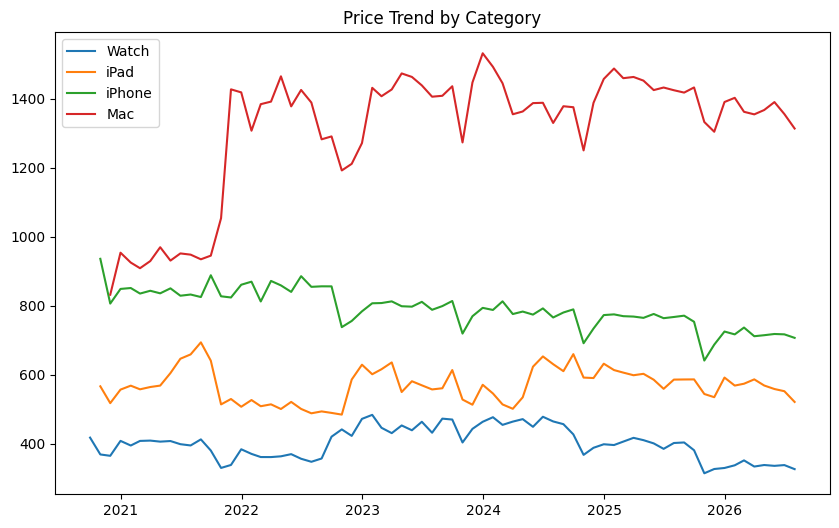

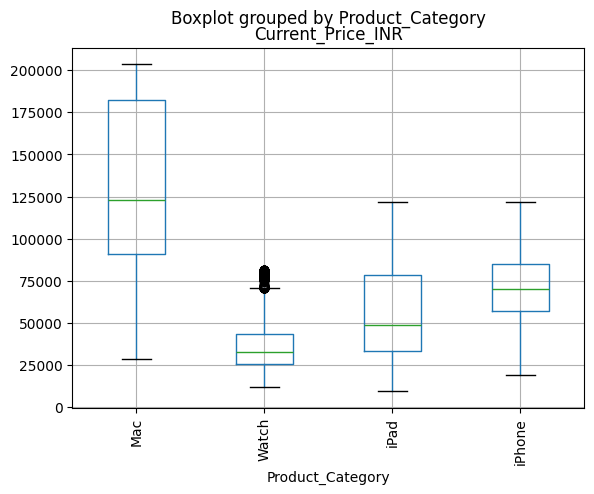

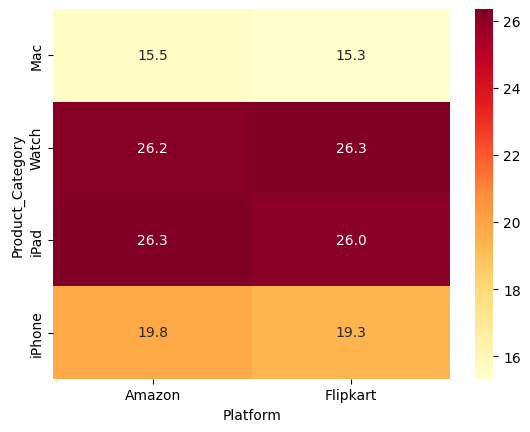

In [19]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

# Line chart: price trend over time by category
fig, ax = plt.subplots(figsize=(10,6))
for cat in df['Product_Category'].unique():
    sub = df[df['Product_Category']==cat].set_index('Date').resample('ME')['Current_Price_USD'].mean()
    ax.plot(sub.index, sub.values, label=cat)
ax.legend(); ax.set_title('Price Trend by Category'); plt.show()

# Boxplot: price distribution by category
df.boxplot(column='Current_Price_INR', by='Product_Category', rot=90)
plt.show()

# Heatmap: platform x category discount
import seaborn as sns
heat_data = df.pivot_table(index='Product_Category', columns='Platform', values='Discount_Pct', aggfunc='mean')
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd')
plt.show()


<StringArray>
[     'Apple Watch Series 6 (44mm)',          'iPad Air (4th Gen) 64GB',
                   'iPhone 12 64GB',              'iPhone 12 Pro 128GB',
             'MacBook Air M1 256GB',      'iPad Pro 11-inch (M1) 128GB',
                  'iPhone 13 128GB',          'iPhone 13 Pro Max 256GB',
              'iPad (9th Gen) 64GB',      'Apple Watch Series 7 (45mm)',
 'MacBook Pro 14-inch M1 Pro 512GB',          'iPad Air (5th Gen) 64GB',
             'MacBook Air M2 256GB',      'Apple Watch Series 8 (45mm)',
                  'iPhone 14 128GB',              'iPhone 14 Pro 128GB',
                'Apple Watch Ultra',    'iPad Pro 12.9-inch (M2) 256GB',
 'MacBook Pro 14-inch M2 Pro 512GB',      'Apple Watch Series 9 (45mm)',
              'Apple Watch Ultra 2',                  'iPhone 15 128GB',
          'iPhone 15 Pro Max 256GB', 'MacBook Pro 14-inch M3 Pro 512GB',
             'MacBook Air M3 256GB',      'iPad Pro 11-inch (M4) 256GB',
                  'iPhone 16 128GB', 

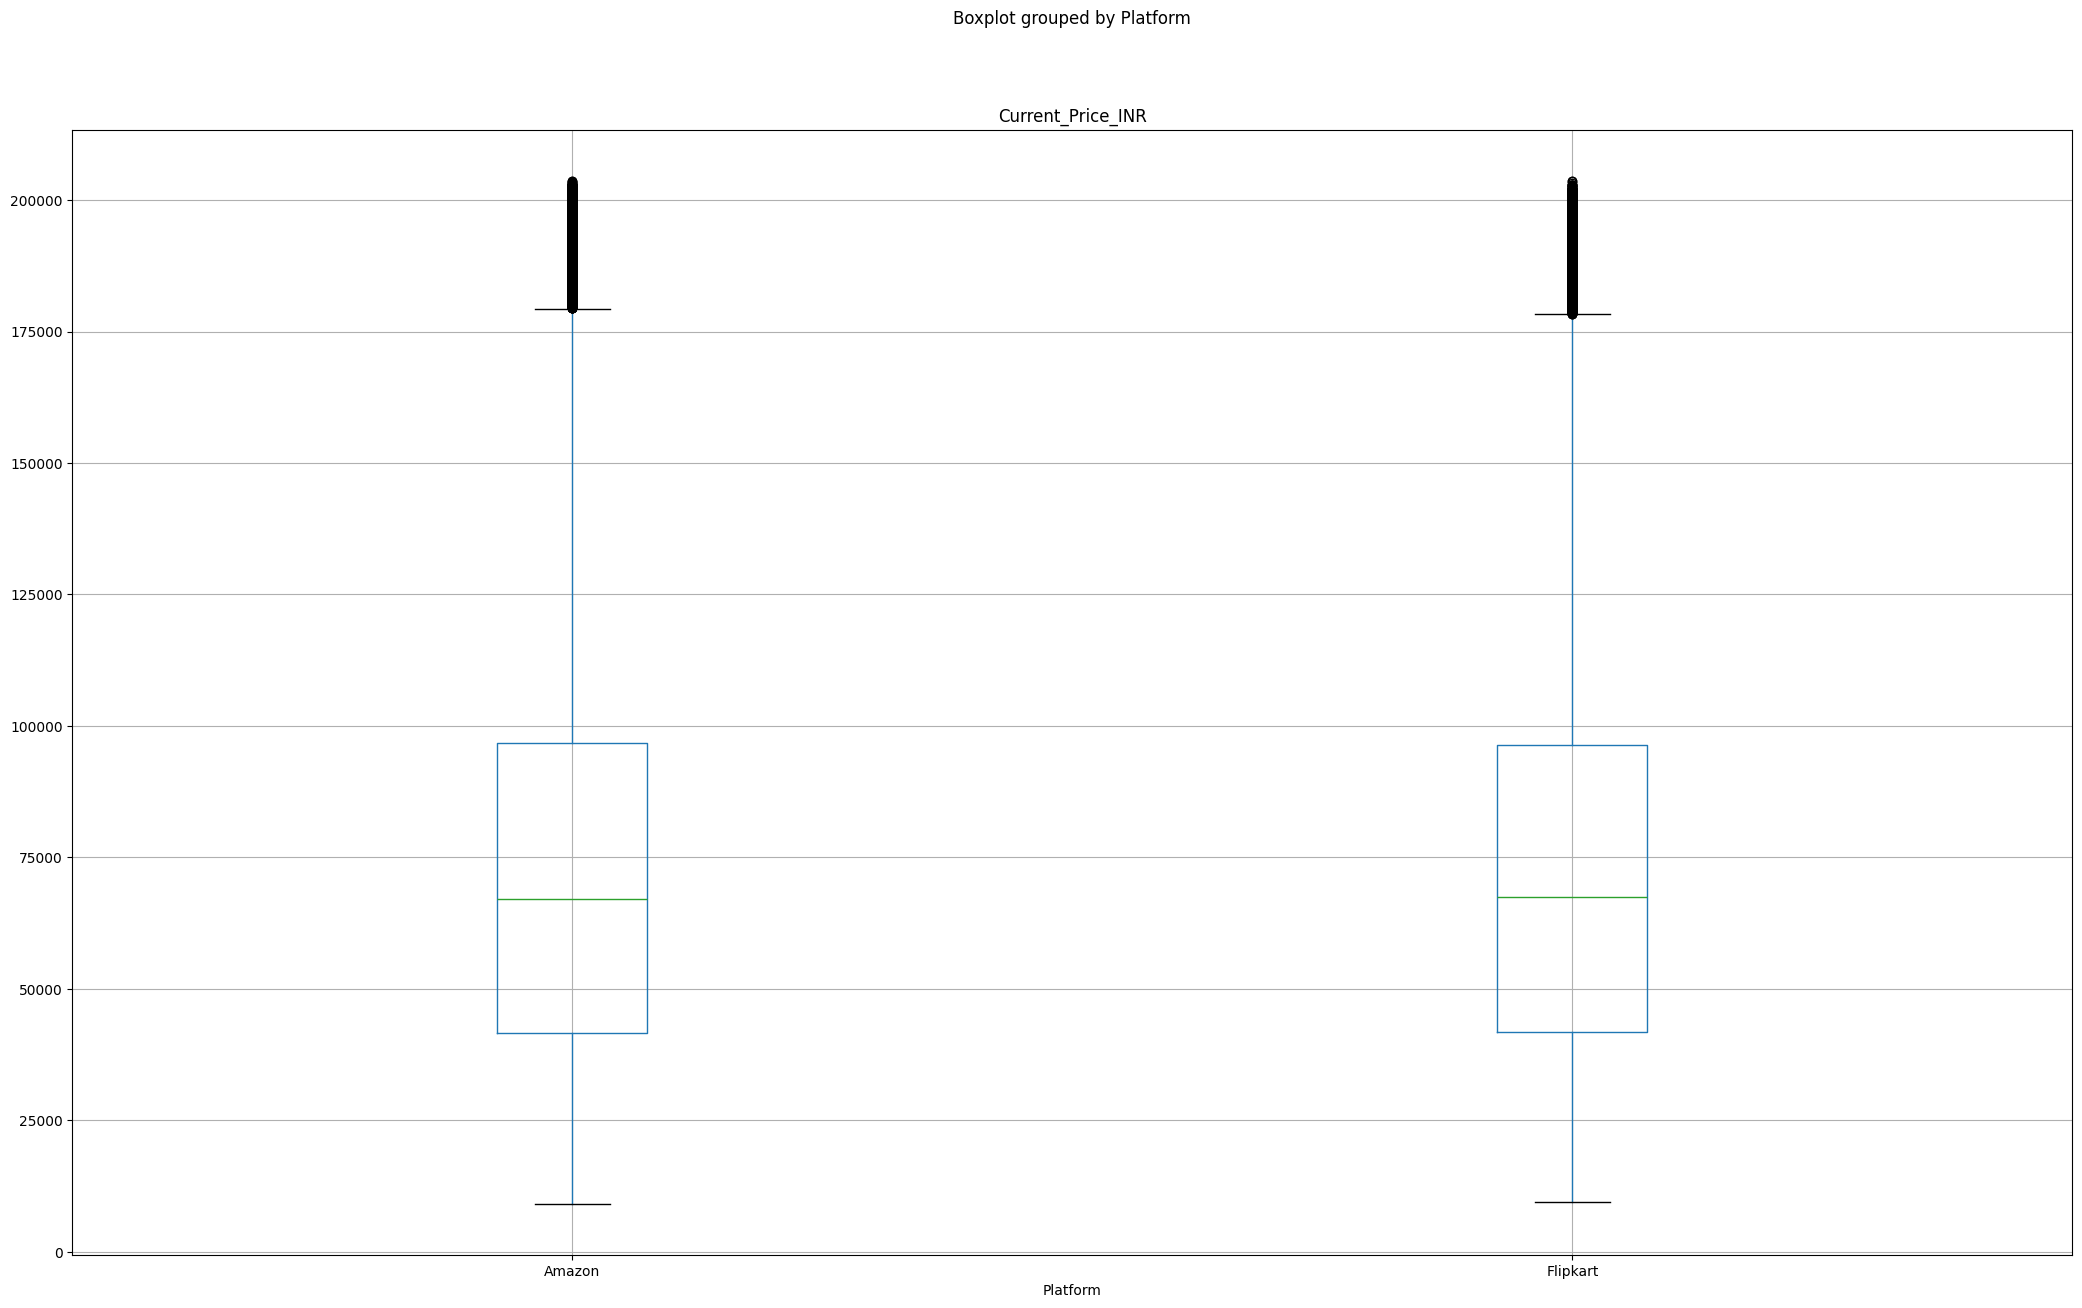

In [20]:

print(df["Model_Name"].unique())# flipcard_amazon_product_wise_boxplot
df.boxplot(column="Current_Price_INR",by="Platform",figsize=(25,15))
plt.show()

                                  Launch_Price_INR  Current_Price_INR
Model_Name                                                           
Apple Watch Series 6 (44mm)                42042.0       26714.168593
Apple Watch Series 7 (45mm)                42042.0       27290.904723
Apple Watch Series 8 (45mm)                42042.0       28667.515384
Apple Watch Series 9 (45mm)                42042.0       30384.168743
Apple Watch Series X (45mm)                42042.0       33670.616643
Apple Watch Ultra                          78302.0       58045.694654
Apple Watch Ultra 2                        78302.0       62097.271576
MacBook Air M1 256GB                       97902.0       68412.273996
MacBook Air M2 256GB                      117502.0       92487.171452
MacBook Air M3 256GB                      107702.0       91117.802240
MacBook Pro 14-inch M1 Pro 512GB          195902.0      160720.879642
MacBook Pro 14-inch M2 Pro 512GB          195902.0      166641.039879
MacBook Pro 14-inch 

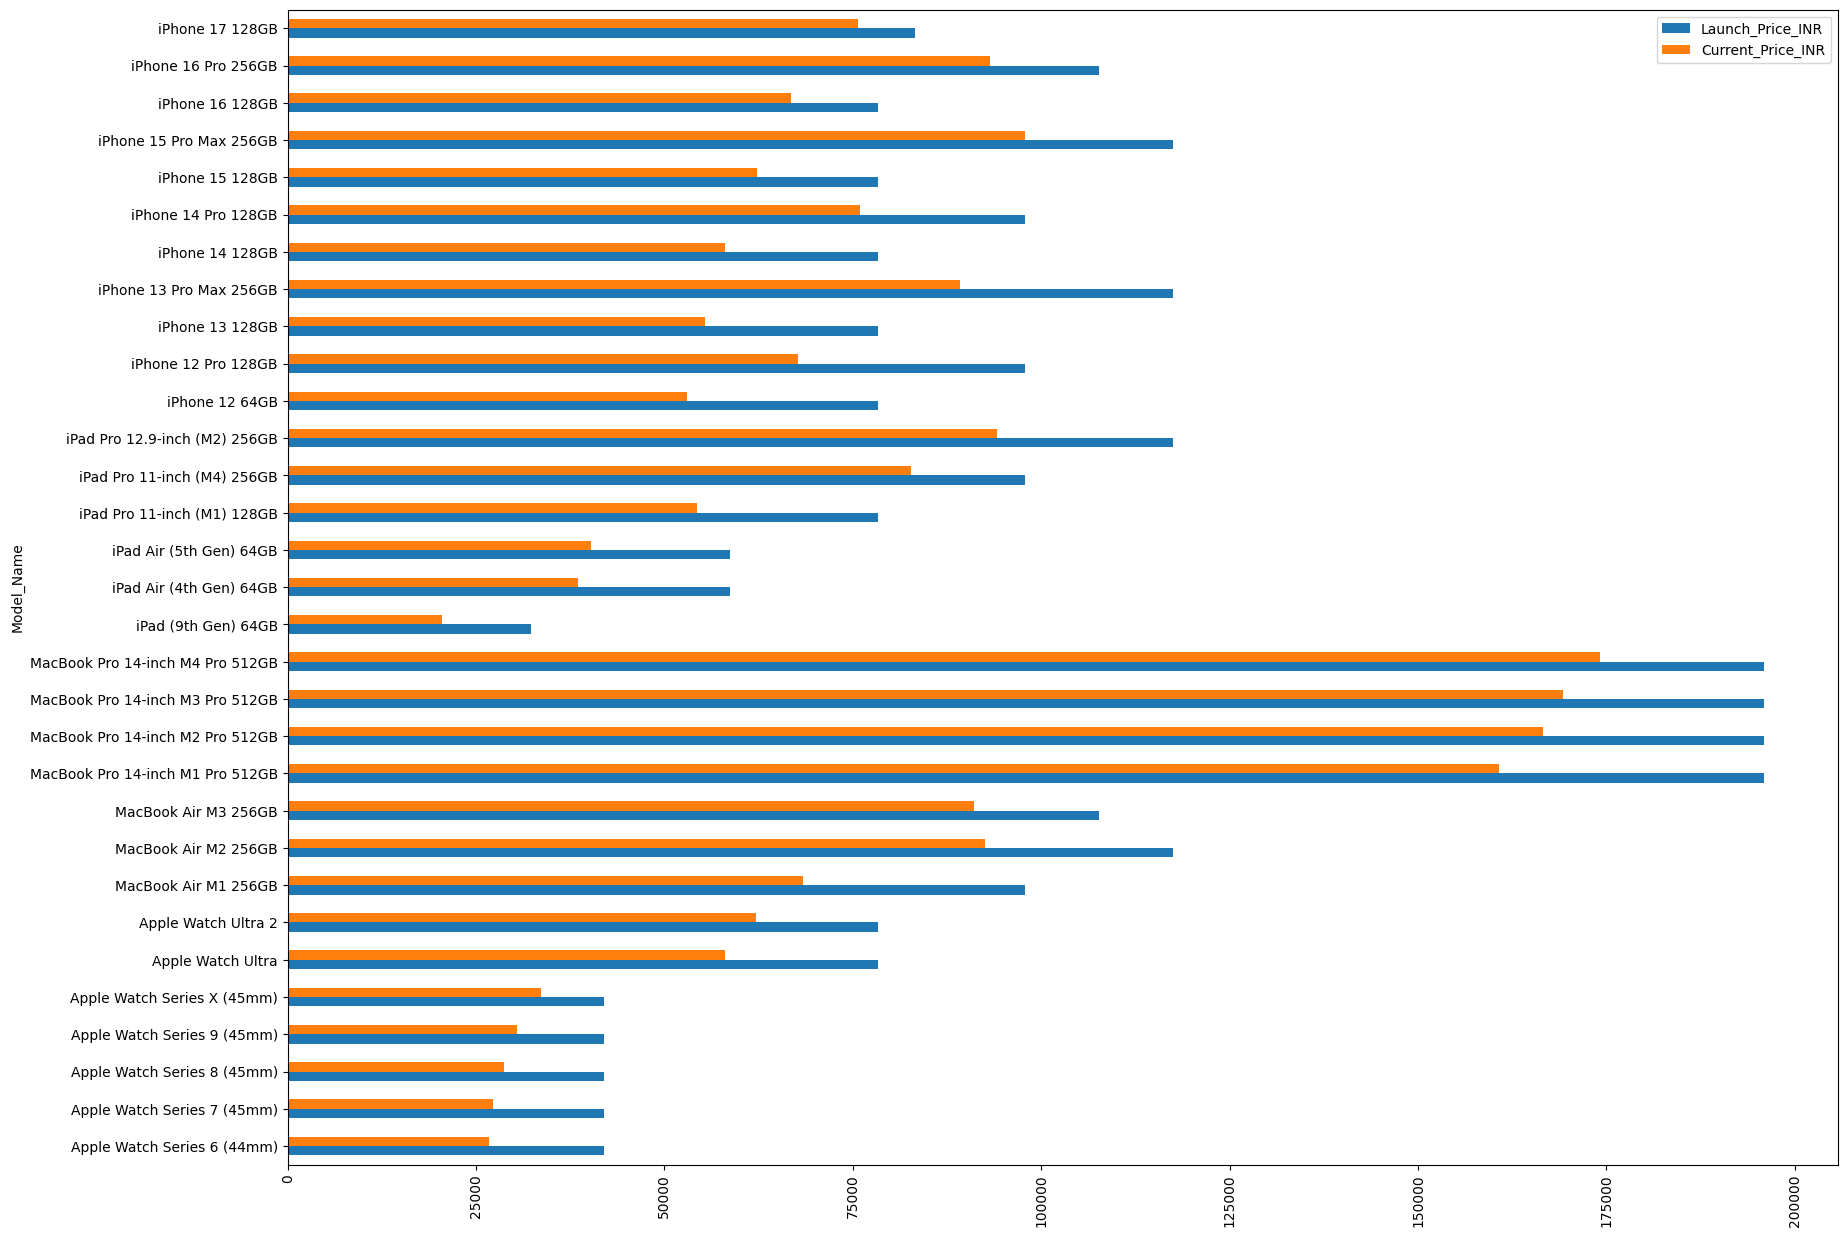

In [21]:
compare = df.groupby("Model_Name")[["Launch_Price_INR", "Current_Price_INR"]].mean()
print(compare)
compare.plot(kind="barh",figsize=(20,15))
plt.xticks(rotation=90)
plt.show()

                                  Launch_Price_INR  Current_Price_INR  \
Model_Name                                                              
Apple Watch Series 6 (44mm)                42042.0       26714.168593   
Apple Watch Series 7 (45mm)                42042.0       27290.904723   
Apple Watch Series 8 (45mm)                42042.0       28667.515384   
Apple Watch Series 9 (45mm)                42042.0       30384.168743   
Apple Watch Series X (45mm)                42042.0       33670.616643   
Apple Watch Ultra                          78302.0       58045.694654   
Apple Watch Ultra 2                        78302.0       62097.271576   
MacBook Air M1 256GB                       97902.0       68412.273996   
MacBook Air M2 256GB                      117502.0       92487.171452   
MacBook Air M3 256GB                      107702.0       91117.802240   
MacBook Pro 14-inch M1 Pro 512GB          195902.0      160720.879642   
MacBook Pro 14-inch M2 Pro 512GB          195902.0 

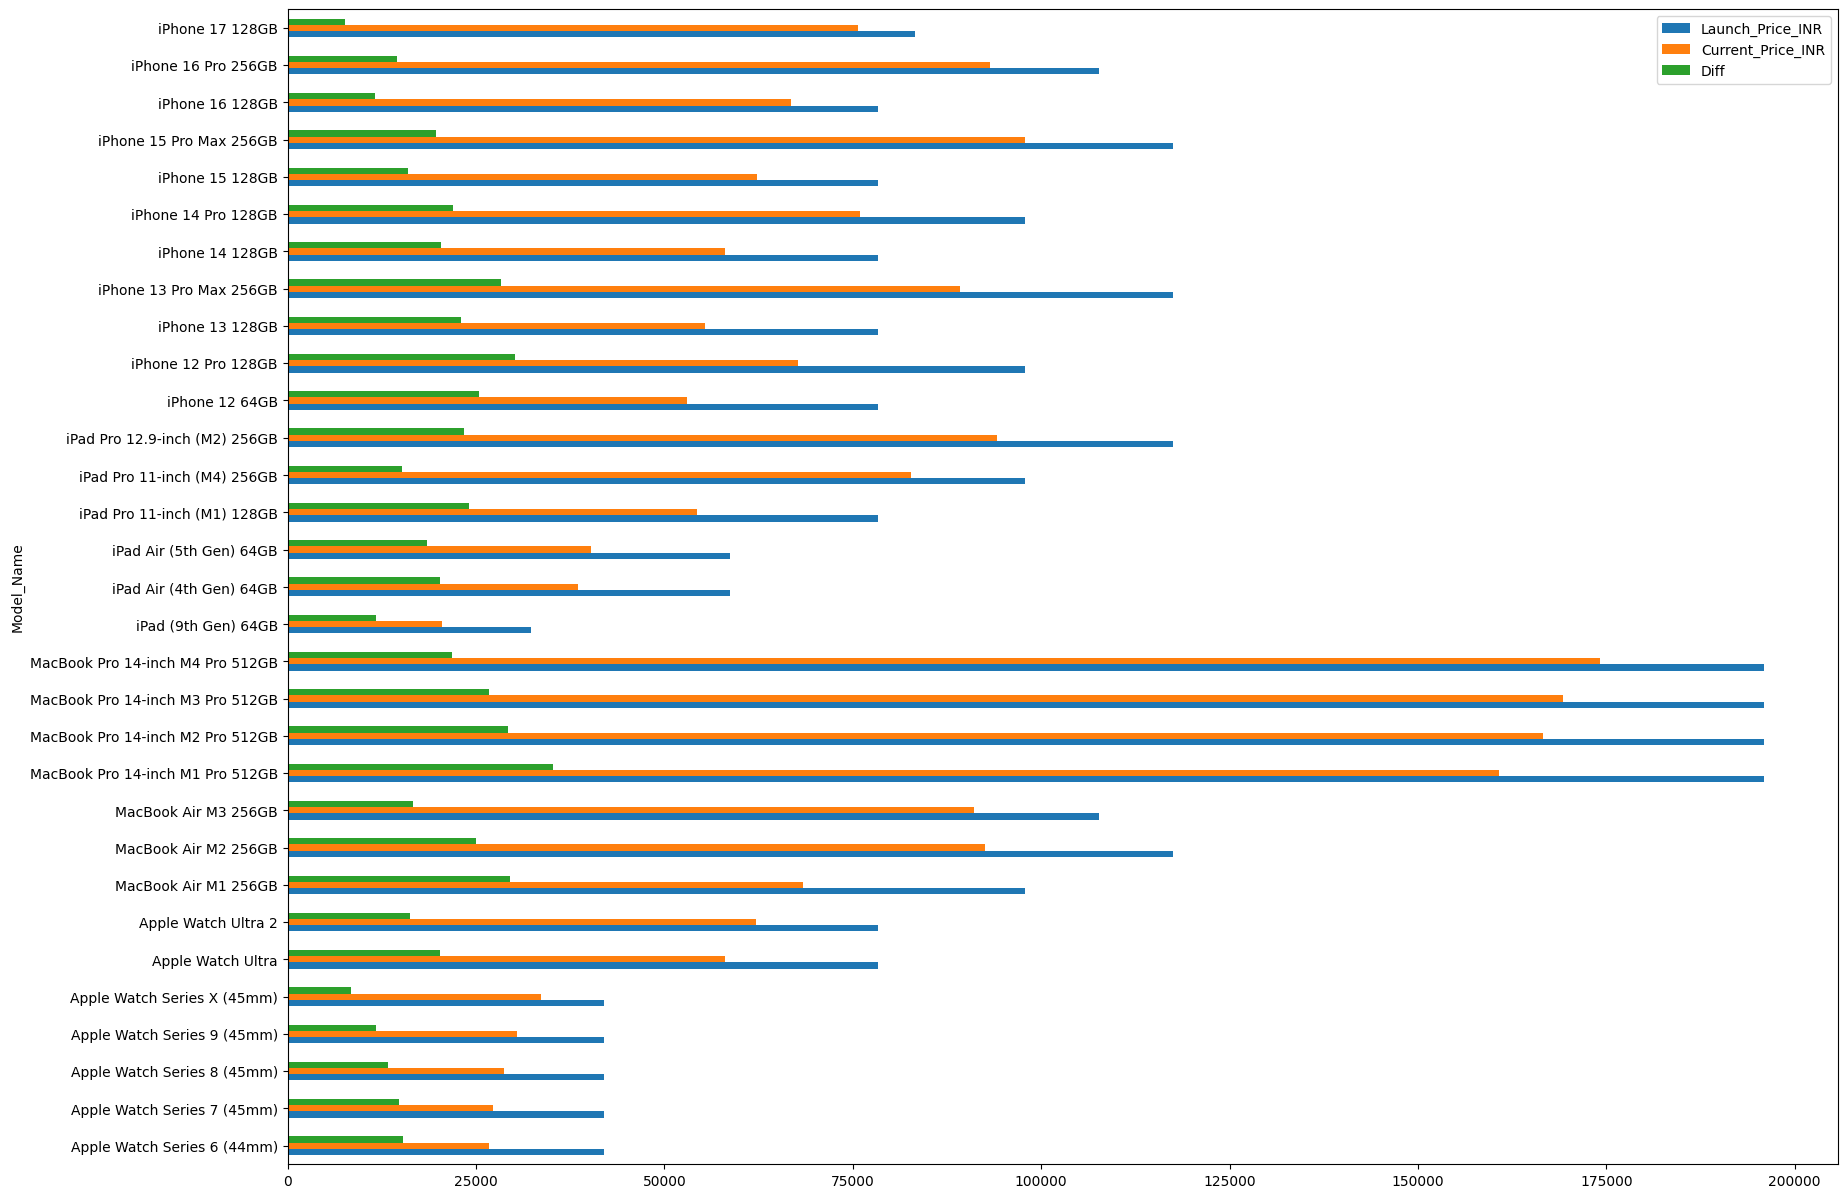

In [22]:
# price difference

df["Diff"] = df["Launch_Price_INR"] - df["Current_Price_INR"]

compare_in_diff_launch_current = df.groupby("Model_Name")[["Launch_Price_INR","Current_Price_INR","Diff"]].mean()
print(compare_in_diff_launch_current)
compare_in_diff_launch_current.plot(kind="barh",figsize=(20,15))
plt.show()